In [ ]:
!git clone https://github.com/pjreddy-ml/text-to-image-ai-project.git

Cloning into 'text-to-image-ai-project'...
remote: Enumerating objects: 117, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 117 (delta 10), reused 34 (delta 4), pack-reused 74 (from 2)
Receiving objects: 100% (117/117), 236.34 MiB | 40.78 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Updating files: 100% (121/121), done.


In [ ]:
!pip install -q torch torchvision transformers matplotlib tqdm

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from transformers import CLIPTokenizer, CLIPTextModel

import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
# Device Configuration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 100
img_size = 64

print("Using device:", device)
print("Latent dimension:", latent_dim)
print("Image size:", img_size)

Using device: cuda
Latent dimension: 100
Image size: 64


In [ ]:
# Image preprocessing

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the landscape dataset
dataset = datasets.ImageFolder(
    root="/content/text-to-image-ai-project/Task1_SD_Finetuning/dataset",
    transform=transform
)

# DataLoader
dataloader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True
)

print("Dataset size:", len(dataset))
print("Number of classes:", len(dataset.classes))
print("Classes:", dataset.classes)
print("Batches per epoch:", len(dataloader))

Dataset size: 50
Number of classes: 1
Classes: ['landscapes']
Batches per epoch: 25


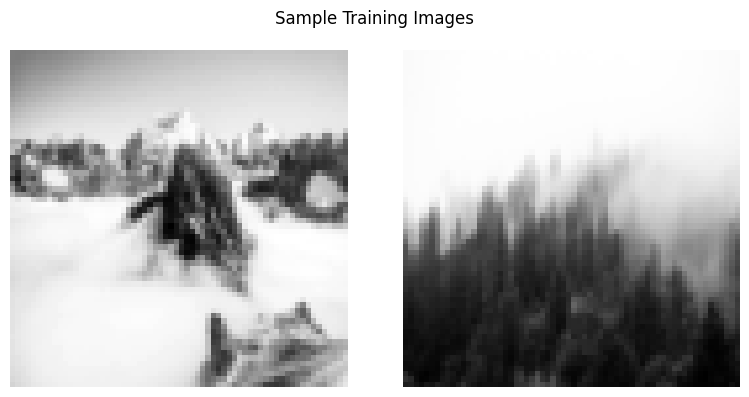

In [ ]:
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(1, len(images), figsize=(8, 4))

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    img = (img + 1) / 2

    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

In [ ]:
# Text Preprocessing

text = "a beautiful landscape with mountains, trees and a blue sky"

print("Input text:", text)

Input text: a beautiful landscape with mountains, trees and a blue sky


In [ ]:
# Text Tokenization

from transformers import CLIPTokenizer

model_name = "openai/clip-vit-base-patch32"

tokenizer = CLIPTokenizer.from_pretrained(model_name)

inputs = tokenizer(
    text,
    padding="max_length",
    truncation=True,
    max_length=77,
    return_tensors="pt"
)

print("Tokenized text shape:", inputs["input_ids"].shape)

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Tokenized text shape: torch.Size([1, 77])


In [ ]:
# Create Text Embeddings

from transformers import CLIPTextModel

text_encoder = CLIPTextModel.from_pretrained(model_name)

with torch.no_grad():
    text_embeddings = text_encoder(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    ).last_hidden_state

print("Text embedding shape:", text_embeddings.shape)

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.l

Text embedding shape: torch.Size([1, 77, 512])


In [ ]:
# GAN Models

import torch
import torch.nn as nn

latent_dim = 100
text_dim = 512
image_size = 64


class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.text_projection = nn.Linear(text_dim, 128)

        self.model = nn.Sequential(
            nn.Linear(latent_dim + 128, 512 * 4 * 4),
            nn.BatchNorm1d(512 * 4 * 4),
            nn.ReLU(True),

            nn.Unflatten(1, (512, 4, 4)),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(32, 1, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, noise, text_embedding):
        text_features = text_embedding.mean(dim=1)
        text_features = self.text_projection(text_features)

        combined = torch.cat((noise, text_features), dim=1)

        return self.model(combined)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.image_features = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.text_projection = nn.Linear(text_dim, 512)

        self.classifier = nn.Sequential(
            nn.Linear(512 * 4 * 4 + 512, 1),
            nn.Sigmoid()
        )

    def forward(self, image, text_embedding):
        image_features = self.image_features(image)
        image_features = image_features.view(image_features.size(0), -1)

        text_features = text_embedding.mean(dim=1)
        text_features = self.text_projection(text_features)

        combined = torch.cat((image_features, text_features), dim=1)

        return self.classifier(combined)


generator = Generator().to(device)
discriminator = Discriminator().to(device)

print("Generator and Discriminator initialized successfully.")

Generator and Discriminator initialized successfully.


In [ ]:
# Training Setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = generator.to(device)
discriminator = discriminator.to(device)
text_embeddings = text_embeddings.to(device)

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

epochs = 50

print("Training device:", device)
print("Models moved to device successfully.")

Training device: cuda
Models moved to device successfully.


In [ ]:
# Train the Text-to-Image GAN

for epoch in range(epochs):

    for real_images, _ in dataloader:

        batch_size = real_images.size(0)

        real_images = real_images.to(device)

        # Match the text embedding to the current batch
        batch_text_embeddings = text_embeddings.expand(
            batch_size, -1, -1
        )

        # Real and fake labels
        real_labels = torch.ones(
            batch_size, 1, device=device
        )

        fake_labels = torch.zeros(
            batch_size, 1, device=device
        )

        # ---------------------
        # Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        real_output = discriminator(
            real_images,
            batch_text_embeddings
        )

        real_loss = criterion(
            real_output,
            real_labels
        )

        noise = torch.randn(
            batch_size,
            latent_dim,
            device=device
        )

        fake_images = generator(
            noise,
            batch_text_embeddings
        )

        fake_output = discriminator(
            fake_images.detach(),
            batch_text_embeddings
        )

        fake_loss = criterion(
            fake_output,
            fake_labels
        )

        d_loss = real_loss + fake_loss

        d_loss.backward()
        optimizer_D.step()

        # ---------------------
        # Train Generator
        # ---------------------

        optimizer_G.zero_grad()

        fake_output = discriminator(
            fake_images,
            batch_text_embeddings
        )

        g_loss = criterion(
            fake_output,
            real_labels
        )

        g_loss.backward()
        optimizer_G.step()

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"| D Loss: {d_loss.item():.4f} "
        f"| G Loss: {g_loss.item():.4f}"
    )

Epoch [1/50] | D Loss: 0.9358 | G Loss: 8.1185
Epoch [2/50] | D Loss: 0.0110 | G Loss: 4.9076
Epoch [3/50] | D Loss: 0.7943 | G Loss: 11.2051
Epoch [4/50] | D Loss: 1.4047 | G Loss: 9.6572
Epoch [5/50] | D Loss: 0.0358 | G Loss: 5.7181
Epoch [6/50] | D Loss: 0.0797 | G Loss: 5.1557
Epoch [7/50] | D Loss: 0.0794 | G Loss: 5.5282
Epoch [8/50] | D Loss: 0.1917 | G Loss: 8.3189
Epoch [9/50] | D Loss: 0.0310 | G Loss: 8.5269
Epoch [10/50] | D Loss: 0.4413 | G Loss: 9.3286
Epoch [11/50] | D Loss: 0.7788 | G Loss: 2.1690
Epoch [12/50] | D Loss: 0.5992 | G Loss: 4.8322
Epoch [13/50] | D Loss: 1.7716 | G Loss: 3.1266
Epoch [14/50] | D Loss: 0.8016 | G Loss: 4.0933
Epoch [15/50] | D Loss: 0.8951 | G Loss: 2.2298
Epoch [16/50] | D Loss: 0.5287 | G Loss: 3.7029
Epoch [17/50] | D Loss: 0.3802 | G Loss: 4.1595
Epoch [18/50] | D Loss: 0.6663 | G Loss: 2.9265
Epoch [19/50] | D Loss: 0.1616 | G Loss: 4.1535
Epoch [20/50] | D Loss: 0.3293 | G Loss: 6.0130
Epoch [21/50] | D Loss: 1.4043 | G Loss: 4.1878


In [ ]:
# Generate Images

generator.eval()

num_samples = 4

noise = torch.randn(
    num_samples,
    latent_dim,
    device=device
)

test_text_embeddings = text_embeddings.expand(
    num_samples, -1, -1
)

with torch.no_grad():
    generated_images = generator(
        noise,
        test_text_embeddings
    ).cpu()

print("Generated image shape:", generated_images.shape)

Generated image shape: torch.Size([4, 1, 64, 64])


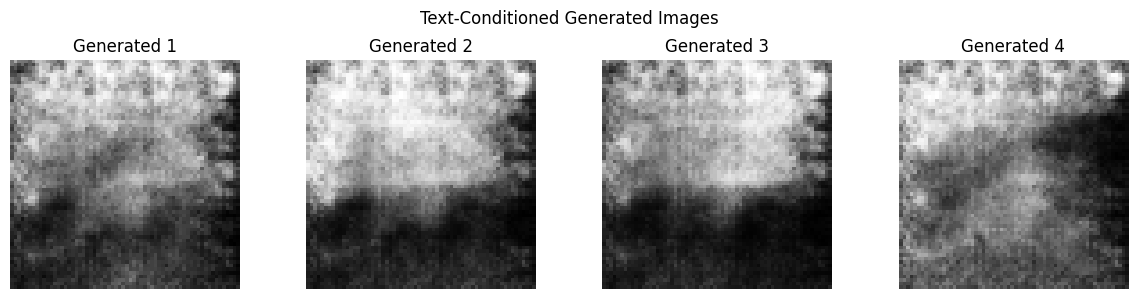

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i, ax in enumerate(axes):
    img = generated_images[i].squeeze().numpy()
    img = (img + 1) / 2

    ax.imshow(img, cmap="gray")
    ax.axis("off")
    ax.set_title(f"Generated {i+1}")

plt.suptitle("Text-Conditioned Generated Images")
plt.tight_layout()
plt.show()